In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mne
from mne.datasets import eegbci
from mne.io import read_raw_edf, concatenate_raws

from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from pyriemann.utils.mean import mean_riemann

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

from mne.decoding import CSP
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [2]:
subjects = list(range(1, 10))
runs = [4, 8, 12]

print("Subjects:", subjects)
print("Runs:", runs)

Subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Runs: [4, 8, 12]


In [4]:
def load_subject_data(subject):
    runs = [4, 8, 12]

    files = eegbci.load_data(subject, runs)
    raws = [read_raw_edf(file, preload=True, verbose=False) for file in files]
    raw = concatenate_raws(raws)

    eegbci.standardize(raw)

    montage = mne.channels.make_standard_montage("standard_1005")
    raw.set_montage(montage, on_missing="ignore")

    raw.filter(8., 30., fir_design="firwin", verbose=False)

    events, event_id = mne.events_from_annotations(raw, verbose=False)

    selected_event_id = {
        "left_hand": event_id["T1"],
        "right_hand": event_id["T2"]
    }

    epochs = mne.Epochs(
        raw,
        events,
        event_id=selected_event_id,
        tmin=1.0,
        tmax=4.0,
        baseline=None,
        preload=True,
        verbose=False
    )

    X = epochs.get_data()
    y = epochs.events[:, -1]
    y = np.where(y == selected_event_id["left_hand"], 0, 1)

    subject_labels = np.full(len(X), subject)

    return X, y, subject_labels

In [5]:
X, y, subject_labels = load_subject_data(1)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("subject labels shape:", subject_labels.shape)
print("Labels:", np.unique(y))
print("Subject:", np.unique(subject_labels))

X shape: (45, 64, 481)
y shape: (45,)
subject labels shape: (45,)
Labels: [0 1]
Subject: [1]


In [6]:
all_X = []
all_y = []
all_subjects = []

for subject in subjects:
    print(f"Loading subject {subject}...")
    
    X, y, subject_labels = load_subject_data(subject)
    
    all_X.append(X)
    all_y.append(y)
    all_subjects.append(subject_labels)

X_all = np.concatenate(all_X, axis=0)
y_all = np.concatenate(all_y, axis=0)
subject_all = np.concatenate(all_subjects, axis=0)

print("All EEG data:", X_all.shape)
print("All labels:", y_all.shape)
print("All subject labels:", subject_all.shape)
print("Subjects:", np.unique(subject_all))

Loading subject 1...
Loading subject 2...
Loading subject 3...
Loading subject 4...
Loading subject 5...
Loading subject 6...
Loading subject 7...
Loading subject 8...
Loading subject 9...
All EEG data: (405, 64, 481)
All labels: (405,)
All subject labels: (405,)
Subjects: [1 2 3 4 5 6 7 8 9]


In [7]:
loso_results = []

for test_subject in subjects:
    print(f"Testing on held-out subject {test_subject}...")
    
    train_idx = subject_all != test_subject
    test_idx = subject_all == test_subject
    
    X_train = X_all[train_idx]
    y_train = y_all[train_idx]
    
    X_test = X_all[test_idx]
    y_test = y_all[test_idx]
    
    model = Pipeline([
        ("cov", Covariances(estimator="oas")),
        ("ts", TangentSpace()),
        ("clf", LogisticRegression(max_iter=1000))
    ])
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    
    loso_results.append({
        "held_out_subject": test_subject,
        "accuracy": acc,
        "n_train_trials": len(X_train),
        "n_test_trials": len(X_test)
    })

loso_results_df = pd.DataFrame(loso_results)

loso_results_df

Testing on held-out subject 1...
Testing on held-out subject 2...
Testing on held-out subject 3...
Testing on held-out subject 4...
Testing on held-out subject 5...
Testing on held-out subject 6...
Testing on held-out subject 7...
Testing on held-out subject 8...
Testing on held-out subject 9...


,held_out_subject,accuracy,n_train_trials,n_test_trials
0,1,0.533333,360,45
1,2,0.511111,360,45
2,3,0.511111,360,45
3,4,0.488889,360,45
4,5,0.533333,360,45
5,6,0.533333,360,45
6,7,0.777778,360,45
7,8,0.533333,360,45
8,9,0.511111,360,45


In [8]:
print("LOSO Riemannian Transfer Results")
print("--------------------------------")
print(loso_results_df)

print("\nMean accuracy:", loso_results_df["accuracy"].mean())
print("Standard deviation:", loso_results_df["accuracy"].std())

LOSO Riemannian Transfer Results
--------------------------------
   held_out_subject  accuracy  n_train_trials  n_test_trials
0                 1  0.533333             360             45
1                 2  0.511111             360             45
2                 3  0.511111             360             45
3                 4  0.488889             360             45
4                 5  0.533333             360             45
5                 6  0.533333             360             45
6                 7  0.777778             360             45
7                 8  0.533333             360             45
8                 9  0.511111             360             45

Mean accuracy: 0.5481481481481482
Standard deviation: 0.08748897637790902


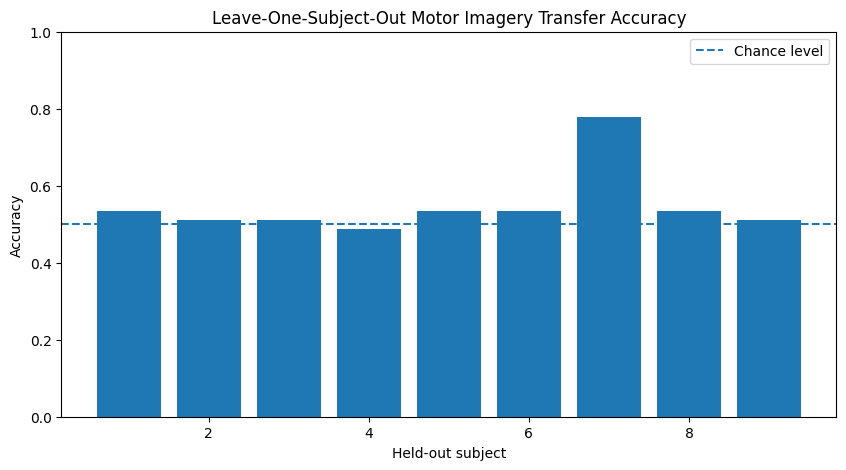

In [9]:
plt.figure(figsize=(10, 5))

plt.bar(
    loso_results_df["held_out_subject"],
    loso_results_df["accuracy"]
)

plt.axhline(
    0.5,
    linestyle="--",
    label="Chance level"
)

plt.xlabel("Held-out subject")
plt.ylabel("Accuracy")
plt.title("Leave-One-Subject-Out Motor Imagery Transfer Accuracy")
plt.ylim(0, 1)
plt.legend()

plt.savefig("../figures/loso_riemannian_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
loso_results_df.to_csv("../results/loso_riemannian_results.csv", index=False)

In [12]:
from scipy.linalg import fractional_matrix_power

def riemannian_align_subject(covs):
    """
    Align covariance matrices for one subject using the inverse square root
    of that subject's Riemannian mean.
    """
    reference = mean_riemann(covs)
    reference_inv_sqrt = fractional_matrix_power(reference, -0.5)

    aligned_covs = np.array([
        reference_inv_sqrt @ cov @ reference_inv_sqrt
        for cov in covs
    ])

    return aligned_covs

In [13]:
cov_estimator = Covariances(estimator="oas")
cov_all = cov_estimator.fit_transform(X_all)

print("Covariance shape:", cov_all.shape)

Covariance shape: (405, 64, 64)


In [14]:
aligned_covs = []
aligned_y = []
aligned_subjects = []

for subject in subjects:
    subject_idx = subject_all == subject
    
    subject_covs = cov_all[subject_idx]
    subject_y = y_all[subject_idx]
    subject_labels = subject_all[subject_idx]
    
    subject_aligned_covs = riemannian_align_subject(subject_covs)
    
    aligned_covs.append(subject_aligned_covs)
    aligned_y.append(subject_y)
    aligned_subjects.append(subject_labels)

cov_aligned_all = np.concatenate(aligned_covs, axis=0)
y_aligned_all = np.concatenate(aligned_y, axis=0)
subject_aligned_all = np.concatenate(aligned_subjects, axis=0)

print("Aligned covariance shape:", cov_aligned_all.shape)

Aligned covariance shape: (405, 64, 64)


In [15]:
aligned_loso_results = []

for test_subject in subjects:
    print(f"Testing on held-out subject {test_subject} with alignment...")
    
    train_idx = subject_aligned_all != test_subject
    test_idx = subject_aligned_all == test_subject
    
    X_train_cov = cov_aligned_all[train_idx]
    y_train = y_aligned_all[train_idx]
    
    X_test_cov = cov_aligned_all[test_idx]
    y_test = y_aligned_all[test_idx]
    
    model = Pipeline([
        ("ts", TangentSpace()),
        ("clf", LogisticRegression(max_iter=1000))
    ])
    
    model.fit(X_train_cov, y_train)
    y_pred = model.predict(X_test_cov)
    
    acc = accuracy_score(y_test, y_pred)
    
    aligned_loso_results.append({
        "held_out_subject": test_subject,
        "accuracy": acc,
        "n_train_trials": len(X_train_cov),
        "n_test_trials": len(X_test_cov)
    })

aligned_loso_results_df = pd.DataFrame(aligned_loso_results)

aligned_loso_results_df

Testing on held-out subject 1 with alignment...
Testing on held-out subject 2 with alignment...
Testing on held-out subject 3 with alignment...
Testing on held-out subject 4 with alignment...
Testing on held-out subject 5 with alignment...
Testing on held-out subject 6 with alignment...
Testing on held-out subject 7 with alignment...
Testing on held-out subject 8 with alignment...
Testing on held-out subject 9 with alignment...


,held_out_subject,accuracy,n_train_trials,n_test_trials
0,1,0.688889,360,45
1,2,0.577778,360,45
2,3,0.444444,360,45
3,4,0.688889,360,45
4,5,0.555556,360,45
5,6,0.555556,360,45
6,7,0.822222,360,45
7,8,0.533333,360,45
8,9,0.511111,360,45


In [16]:
print("Baseline Riemannian:")
print(f"{loso_results_df['accuracy'].mean():.3f} ± {loso_results_df['accuracy'].std():.3f}")

print("Aligned Riemannian:")
print(f"{aligned_loso_results_df['accuracy'].mean():.3f} ± {aligned_loso_results_df['accuracy'].std():.3f}")

Baseline Riemannian:
0.548 ± 0.087
Aligned Riemannian:
0.598 ± 0.115


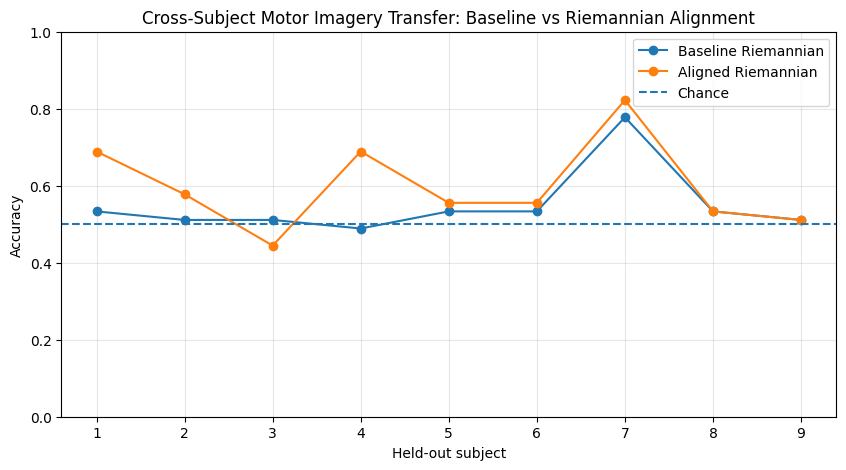

In [17]:
comparison_df = pd.DataFrame({
    "held_out_subject": loso_results_df["held_out_subject"],
    "baseline": loso_results_df["accuracy"],
    "aligned": aligned_loso_results_df["accuracy"]
})

plt.figure(figsize=(10, 5))

plt.plot(
    comparison_df["held_out_subject"],
    comparison_df["baseline"],
    marker="o",
    label="Baseline Riemannian"
)

plt.plot(
    comparison_df["held_out_subject"],
    comparison_df["aligned"],
    marker="o",
    label="Aligned Riemannian"
)

plt.axhline(0.5, linestyle="--", label="Chance")

plt.xlabel("Held-out subject")
plt.ylabel("Accuracy")
plt.title("Cross-Subject Motor Imagery Transfer: Baseline vs Riemannian Alignment")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)

plt.savefig("../figures/alignment_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [18]:
aligned_loso_results_df.to_csv("../results/loso_aligned_riemannian_results.csv", index=False)
comparison_df.to_csv("../results/alignment_comparison_results.csv", index=False)

In [19]:
summary_df = pd.DataFrame({
    "model": ["Baseline Riemannian", "Aligned Riemannian"],
    "mean_accuracy": [
        loso_results_df["accuracy"].mean(),
        aligned_loso_results_df["accuracy"].mean()
    ],
    "std_accuracy": [
        loso_results_df["accuracy"].std(),
        aligned_loso_results_df["accuracy"].std()
    ]
})

summary_df

,model,mean_accuracy,std_accuracy
0,Baseline Riemannian,0.548148,0.087489
1,Aligned Riemannian,0.597531,0.115173


In [20]:
summary_df.to_csv("../results/model_summary.csv", index=False)

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [23]:
X_deep = X_all[:, np.newaxis, :, :]
y_deep = y_all

print(X_deep.shape)
print(y_deep.shape)

(405, 1, 64, 481)
(405,)


In [24]:
class SimpleEEGNet(nn.Module):
    def __init__(self, n_channels, n_times, n_classes=2):
        super(SimpleEEGNet, self).__init__()

        self.temporal = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=(1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(8)
        )

        self.spatial = nn.Sequential(
            nn.Conv2d(8, 16, kernel_size=(n_channels, 1), groups=8, bias=False),
            nn.BatchNorm2d(16),
            nn.ELU(),
            nn.AvgPool2d(kernel_size=(1, 4)),
            nn.Dropout(0.5)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * (n_times // 4), n_classes)
        )

    def forward(self, x):
        x = self.temporal(x)
        x = self.spatial(x)
        x = self.classifier(x)
        return x

In [25]:
def train_eegnet_loso(test_subject, n_epochs=20, batch_size=32, lr=0.001):
    train_idx = subject_all != test_subject
    test_idx = subject_all == test_subject

    X_train = X_deep[train_idx]
    y_train = y_deep[train_idx]

    X_test = X_deep[test_idx]
    y_test = y_deep[test_idx]

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)

    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    n_channels = X_train.shape[2]
    n_times = X_train.shape[3]

    model = SimpleEEGNet(
        n_channels=n_channels,
        n_times=n_times,
        n_classes=2
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    model.train()

    for epoch in range(n_epochs):
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()

            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            loss.backward()
            optimizer.step()

    model.eval()

    with torch.no_grad():
        X_test_tensor = X_test_tensor.to(device)
        outputs = model(X_test_tensor)
        y_pred = torch.argmax(outputs, dim=1).cpu().numpy()

    acc = accuracy_score(y_test, y_pred)

    return acc

In [26]:
eegnet_results = []

for test_subject in subjects:
    print(f"Training EEGNet, held-out subject {test_subject}...")

    acc = train_eegnet_loso(
        test_subject=test_subject,
        n_epochs=20,
        batch_size=32,
        lr=0.001
    )

    eegnet_results.append({
        "held_out_subject": test_subject,
        "accuracy": acc
    })

eegnet_results_df = pd.DataFrame(eegnet_results)
eegnet_results_df

Training EEGNet, held-out subject 1...
Training EEGNet, held-out subject 2...
Training EEGNet, held-out subject 3...
Training EEGNet, held-out subject 4...
Training EEGNet, held-out subject 5...
Training EEGNet, held-out subject 6...
Training EEGNet, held-out subject 7...
Training EEGNet, held-out subject 8...
Training EEGNet, held-out subject 9...


,held_out_subject,accuracy
0,1,0.488889
1,2,0.355556
2,3,0.511111
3,4,0.644444
4,5,0.488889
5,6,0.422222
6,7,0.444444
7,8,0.466667
8,9,0.600000


In [27]:
print("EEGNet LOSO Results")
print("-------------------")
print(f"Mean accuracy: {eegnet_results_df['accuracy'].mean():.3f}")
print(f"Std accuracy: {eegnet_results_df['accuracy'].std():.3f}")

EEGNet LOSO Results
-------------------
Mean accuracy: 0.491
Std accuracy: 0.088


In [28]:
eegnet_results_df.to_csv("../results/loso_eegnet_results.csv", index=False)

final_summary_df = pd.DataFrame({
    "model": [
        "Baseline Riemannian",
        "Aligned Riemannian",
        "Simple EEGNet"
    ],
    "mean_accuracy": [
        loso_results_df["accuracy"].mean(),
        aligned_loso_results_df["accuracy"].mean(),
        eegnet_results_df["accuracy"].mean()
    ],
    "std_accuracy": [
        loso_results_df["accuracy"].std(),
        aligned_loso_results_df["accuracy"].std(),
        eegnet_results_df["accuracy"].std()
    ]
})

final_summary_df

,model,mean_accuracy,std_accuracy
0,Baseline Riemannian,0.548148,0.087489
1,Aligned Riemannian,0.597531,0.115173
2,Simple EEGNet,0.491358,0.087802


In [29]:
final_summary_df.to_csv("../results/final_model_comparison.csv", index=False)

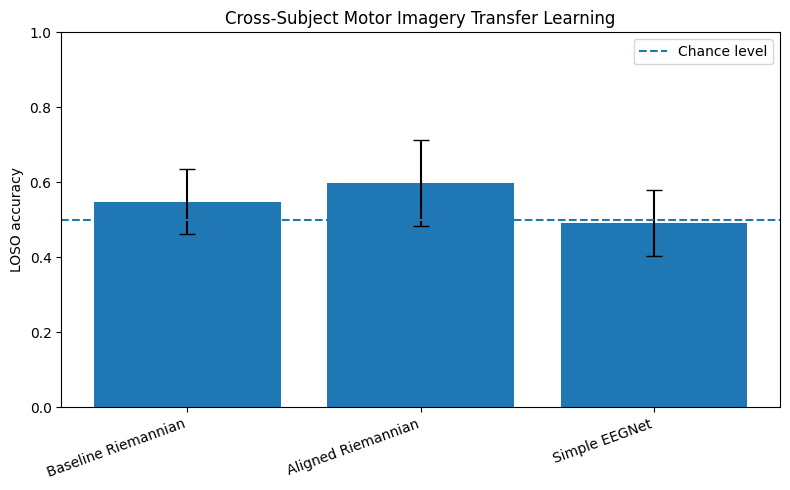

In [30]:
plt.figure(figsize=(8, 5))

plt.bar(
    final_summary_df["model"],
    final_summary_df["mean_accuracy"],
    yerr=final_summary_df["std_accuracy"],
    capsize=6
)

plt.axhline(0.5, linestyle="--", label="Chance level")

plt.ylabel("LOSO accuracy")
plt.title("Cross-Subject Motor Imagery Transfer Learning")
plt.ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend()
plt.tight_layout()

plt.savefig("../figures/final_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [32]:
fusion_results = []

for test_subject in subjects:
    print(f"Testing fusion model on held-out subject {test_subject}...")

    train_idx = subject_all != test_subject
    test_idx = subject_all == test_subject

    X_train = X_all[train_idx]
    y_train = y_all[train_idx]

    X_test = X_all[test_idx]
    y_test = y_all[test_idx]

    # ---------- RCSP FEATURES ----------
    csp = CSP(
        n_components=6,
        reg="ledoit_wolf",
        log=True,
        norm_trace=False
    )

    X_train_csp = csp.fit_transform(X_train, y_train)
    X_test_csp = csp.transform(X_test)

    # ---------- RIEMANNIAN FEATURES ----------
    cov_estimator = Covariances(estimator="oas")

    cov_train = cov_estimator.fit_transform(X_train)
    cov_test = cov_estimator.transform(X_test)

    # Subject-specific alignment on training subjects
    aligned_train_covs = []
    aligned_train_y = []

    train_subjects = subject_all[train_idx]

    for subject in np.unique(train_subjects):
        subject_mask = train_subjects == subject
        subject_covs = cov_train[subject_mask]

        aligned_subject_covs = riemannian_align_subject(subject_covs)

        aligned_train_covs.append(aligned_subject_covs)
        aligned_train_y.append(y_train[subject_mask])

    cov_train_aligned = np.concatenate(aligned_train_covs, axis=0)
    y_train_aligned = np.concatenate(aligned_train_y, axis=0)

    # Align test subject independently
    cov_test_aligned = riemannian_align_subject(cov_test)

    ts = TangentSpace()

    X_train_riem = ts.fit_transform(cov_train_aligned)
    X_test_riem = ts.transform(cov_test_aligned)

    # ---------- FEATURE CONCATENATION ----------
    X_train_fused = np.hstack([
        X_train_csp,
        X_train_riem
    ])

    X_test_fused = np.hstack([
        X_test_csp,
        X_test_riem
    ])

    # ---------- CLASSIFIER ----------
    clf = make_pipeline(
        StandardScaler(),
        SVC(kernel="linear", C=1.0)
    )

    clf.fit(X_train_fused, y_train_aligned)
    y_pred = clf.predict(X_test_fused)

    acc = accuracy_score(y_test, y_pred)

    fusion_results.append({
        "held_out_subject": test_subject,
        "accuracy": acc,
        "n_train_trials": len(X_train),
        "n_test_trials": len(X_test)
    })

fusion_results_df = pd.DataFrame(fusion_results)
fusion_results_df

Testing fusion model on held-out subject 1...
Computing rank from data with rank=None
    Using tolerance 0.00055 (2.2e-16 eps * 64 dim * 3.9e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Testing fusion model on held-out subject 2...
Computing rank from data with rank=None
    Using tolerance 0.00059 (2.2e-16 eps * 64 dim * 4.2e+10  max singular value)
    Estimated rank (data): 64
    data: rank 64 computed from 64 data channels with 0 projectors
Reducing data rank from 64 -> 64
Estimating class=0 covariance using LEDOIT_WOLF
Done.
Estimating class=1 covariance using LEDOIT_WOLF
Done.
Testing fusion model on held-out subject 3...
Computing rank from data with rank=None
    Using tolerance 0.00052 (2.2e-16 eps * 64 dim * 3.7e+10  max singular value)
    Estimated rank (dat

,held_out_subject,accuracy,n_train_trials,n_test_trials
0,1,0.644444,360,45
1,2,0.644444,360,45
2,3,0.533333,360,45
3,4,0.622222,360,45
4,5,0.533333,360,45
5,6,0.666667,360,45
6,7,0.777778,360,45
7,8,0.533333,360,45
8,9,0.577778,360,45


In [33]:
print("Fusion Model LOSO Results")
print("-------------------------")
print(f"Mean accuracy: {fusion_results_df['accuracy'].mean():.3f}")
print(f"Std accuracy: {fusion_results_df['accuracy'].std():.3f}")

Fusion Model LOSO Results
-------------------------
Mean accuracy: 0.615
Std accuracy: 0.081


In [34]:
final_summary_df = pd.DataFrame({
    "model": [
        "Baseline Riemannian",
        "Aligned Riemannian",
        "Simple EEGNet",
        "RCSP + Riemannian Fusion"
    ],
    "mean_accuracy": [
        loso_results_df["accuracy"].mean(),
        aligned_loso_results_df["accuracy"].mean(),
        eegnet_results_df["accuracy"].mean(),
        fusion_results_df["accuracy"].mean()
    ],
    "std_accuracy": [
        loso_results_df["accuracy"].std(),
        aligned_loso_results_df["accuracy"].std(),
        eegnet_results_df["accuracy"].std(),
        fusion_results_df["accuracy"].std()
    ]
})

final_summary_df

,model,mean_accuracy,std_accuracy
0,Baseline Riemannian,0.548148,0.087489
1,Aligned Riemannian,0.597531,0.115173
2,Simple EEGNet,0.491358,0.087802
3,RCSP + Riemannian Fusion,0.614815,0.080890


In [35]:
fusion_results_df.to_csv("../results/loso_fusion_results.csv", index=False)
final_summary_df.to_csv("../results/final_model_comparison.csv", index=False)

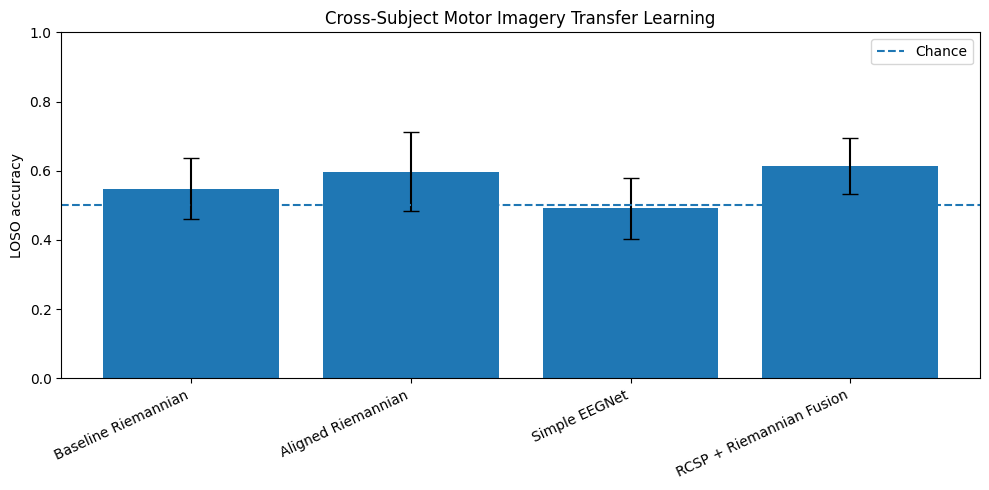

In [36]:
plt.figure(figsize=(10, 5))

plt.bar(
    final_summary_df["model"],
    final_summary_df["mean_accuracy"],
    yerr=final_summary_df["std_accuracy"],
    capsize=6
)

plt.axhline(0.5, linestyle="--", label="Chance")

plt.ylabel("LOSO accuracy")
plt.title("Cross-Subject Motor Imagery Transfer Learning")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.legend()
plt.tight_layout()

plt.savefig("../figures/final_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
fusion_results_df.to_csv("../results/loso_fusion_results.csv", index=False)
final_summary_df.to_csv("../results/final_model_comparison.csv", index=False)

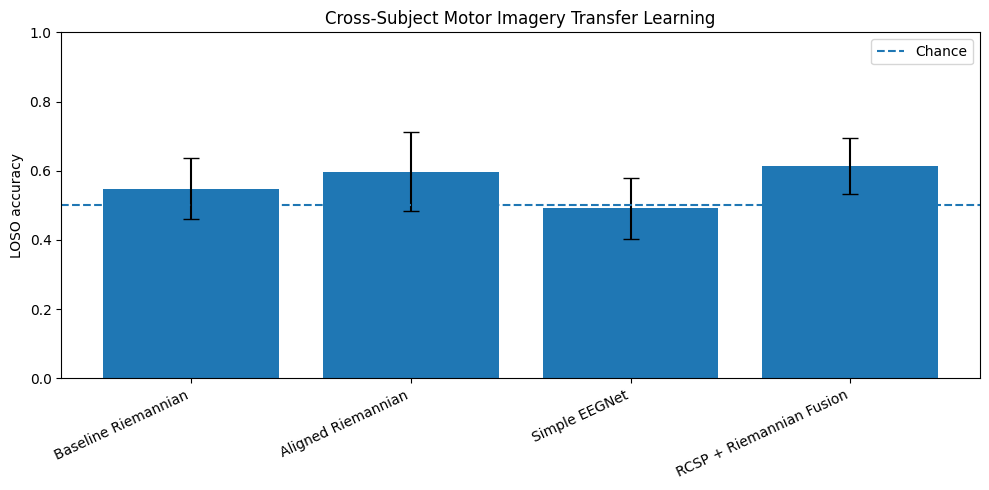

In [38]:
plt.figure(figsize=(10, 5))

plt.bar(
    final_summary_df["model"],
    final_summary_df["mean_accuracy"],
    yerr=final_summary_df["std_accuracy"],
    capsize=6
)

plt.axhline(0.5, linestyle="--", label="Chance")

plt.ylabel("LOSO accuracy")
plt.title("Cross-Subject Motor Imagery Transfer Learning")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.legend()
plt.tight_layout()

plt.savefig("../figures/final_model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()